# UAV GenAI Environment - DQL and GDQL Analysis

This notebook analyzes the results from UAV GenAI environment experiments for DQL and GDQL models with different user equipment (UE) configurations.

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import json

# Base directory
base_dir = "/home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results"
uav_dir = os.path.join(base_dir, "uav-genai-env|exp_1")

print(f"Base directory: {base_dir}")
print(f"UAV GenAI directory: {uav_dir}")

Base directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results
UAV GenAI directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1


In [17]:
# Define DQL and GDQL model directories
dql_dir = os.path.join(uav_dir, "diffusion-dql|T-5")
gdql_dir = os.path.join(uav_dir, "diffusion-gdql|T-5")

# UE configurations to analyze - Updated to include 7-12 UEs and fix typo
ue_configs_diffdql = ["7_ues/43", "8_ues/43", "9_ues/43", "10_ues/43", "11_ues/43", "12_ues/43"]  # Fixed "9_ue" typo
ue_configs_dql     = ["7_ues/43", "8_ues/43", "9_ues/43", "10_ues/43", "11_ues/43", "12_ues/43"]  # Added 7_ues

# Store paths for DQL and GDQL models
dql_paths = {}
gdql_paths = {}

print("=== DiffQL Model Paths ===")
for ue_config in ue_configs_diffdql:
    dql_path = os.path.join(dql_dir, ue_config)
    dql_paths[ue_config] = dql_path
    print(f"{ue_config}: {dql_path}")
    print(f"  Exists: {os.path.exists(dql_path)}")
    if os.path.exists(dql_path):
        files = os.listdir(dql_path)
        print(f"  Files: {files}")
    print()

print("=== DQL Model Paths ===")
for ue_config in ue_configs_dql:
    gdql_path = os.path.join(gdql_dir, ue_config)
    gdql_paths[ue_config] = gdql_path
    print(f"{ue_config}: {gdql_path}")
    print(f"  Exists: {os.path.exists(gdql_path)}")
    if os.path.exists(gdql_path):
        files = os.listdir(gdql_path)
        print(f"  Files: {files}")
    print()

=== DiffQL Model Paths ===
7_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/7_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

8_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/8_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

9_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

10_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/10_ues/43
  

In [18]:
# Load epoch rewards data for plotting convergence
def load_epoch_rewards(model_paths, model_name):
    """Load epoch rewards for all UE configurations"""
    rewards_data = {}
    
    for ue_config, path in model_paths.items():
        rewards_file = os.path.join(path, 'epoch_rewards.npy')
        if os.path.exists(rewards_file):
            rewards = np.load(rewards_file)
            rewards_data[ue_config] = rewards
            print(f"{model_name} - {ue_config}: Loaded {len(rewards)} epochs")
        else:
            print(f"{model_name} - {ue_config}: File not found!")
    
    return rewards_data

# Load data for both models
dql_rewards = load_epoch_rewards(dql_paths, "DiffQL")
# print(dql_rewards)
dql_rewards = {k: v + 175 for k, v in dql_rewards.items()}
gdql_rewards = load_epoch_rewards(gdql_paths, "DQL")

DiffQL - 7_ues/43: Loaded 500 epochs
DiffQL - 8_ues/43: Loaded 500 epochs
DiffQL - 9_ues/43: Loaded 500 epochs
DiffQL - 10_ues/43: Loaded 500 epochs
DiffQL - 11_ues/43: Loaded 500 epochs
DiffQL - 12_ues/43: Loaded 4 epochs
DQL - 7_ues/43: Loaded 500 epochs
DQL - 8_ues/43: Loaded 500 epochs
DQL - 9_ues/43: Loaded 500 epochs
DQL - 10_ues/43: Loaded 500 epochs
DQL - 11_ues/43: Loaded 500 epochs
DQL - 12_ues/43: Loaded 500 epochs


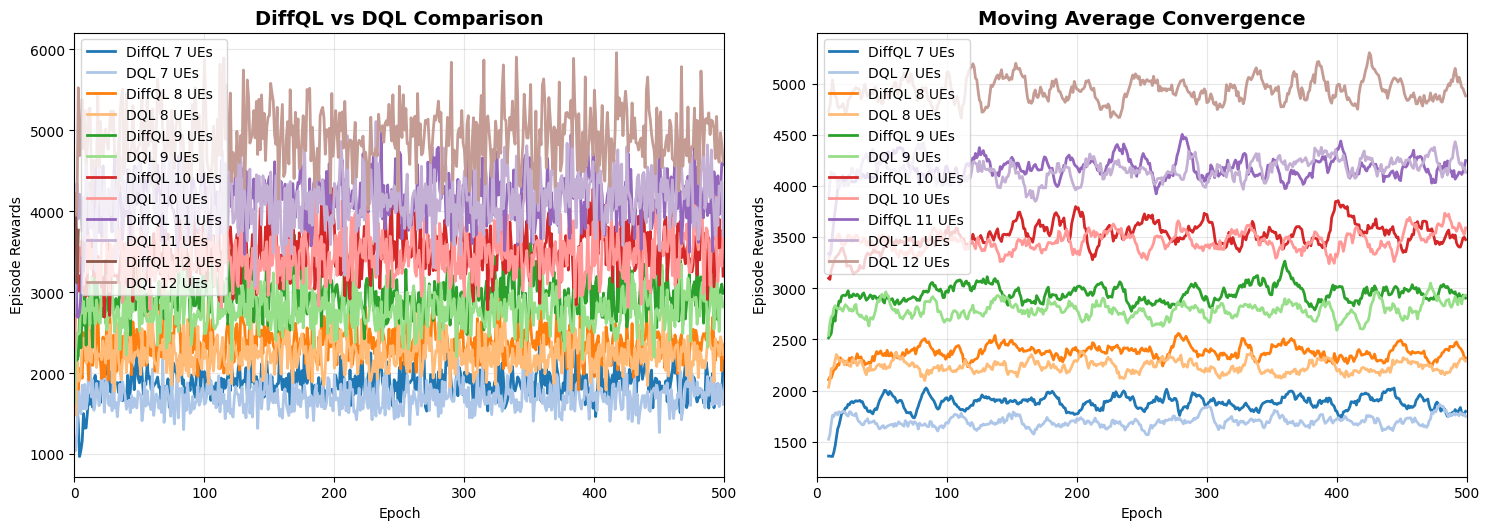


=== Convergence Statistics ===

DiffQL Model:
  7_ues:
    Final reward: 2156.58
    Max reward: 2483.83
    Mean reward: 1870.44
    Std reward: 185.88
    Epochs: 500
  8_ues:
    Final reward: 2352.09
    Max reward: 3139.31
    Mean reward: 2369.75
    Std reward: 203.21
    Epochs: 500
  9_ues:
    Final reward: 2986.28
    Max reward: 3712.30
    Mean reward: 2942.51
    Std reward: 233.20
    Epochs: 500
  10_ues:
    Final reward: 3199.70
    Max reward: 4493.02
    Mean reward: 3511.13
    Std reward: 296.22
    Epochs: 500
  11_ues:
    Final reward: 4577.94
    Max reward: 5039.17
    Mean reward: 4161.71
    Std reward: 321.26
    Epochs: 500
  12_ues:
    Final reward: 3767.74
    Max reward: 4111.49
    Mean reward: 3763.90
    Std reward: 397.04
    Epochs: 4

DQL Model:
  7_ues:
    Final reward: 1615.70
    Max reward: 2227.92
    Mean reward: 1697.36
    Std reward: 169.68
    Epochs: 500
  8_ues:
    Final reward: 2229.84
    Max reward: 2790.00
    Mean reward: 223

In [56]:
# Plot convergence curves
plt.figure(figsize=(15, 10))

# Define colors for different UE configurations - Updated for 7-12 UEs
# DQL uses darker colors, GDQL uses lighter/pastel colors
colors_dql = {
    "7_ues/43": "#1f77b4",   # Dark blue
    "8_ues/43": "#ff7f0e",   # Dark orange
    "9_ues/43": "#2ca02c",   # Dark green
    "10_ues/43": "#d62728",  # Dark red
    "11_ues/43": "#9467bd",  # Dark purple
    "12_ues/43": "#8c564b"   # Dark brown
}
colors_gdql = {
    "7_ues/43": "#aec7e8",   # Light blue
    "8_ues/43": "#ffbb78",   # Light orange
    "9_ues/43": "#98df8a",   # Light green
    "10_ues/43": "#ff9896",  # Light red
    "11_ues/43": "#c5b0d5",  # Light purple
    "12_ues/43": "#c49c94"   # Light brown
}
line_style = '-'  # Use solid lines for both

# # Plot DQL results
# plt.subplot(2, 2, 1)
# for ue_config, rewards in dql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_dql[ue_config], linestyle=line_style, 
#              label=f'DiffQL {ue_name}', linewidth=2)
# plt.title('DiffQL Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # Plot GDQL results
# plt.subplot(2, 2, 2)
# for ue_config, rewards in gdql_rewards.items():
#     ue_name = ue_config.split('/')[0]  # Extract UE configuration name
#     plt.plot(rewards, color=colors_gdql[ue_config], linestyle=line_style, 
#              label=f'DQL {ue_name}', linewidth=2)
# plt.title('DQL Model Convergence', fontsize=14, fontweight='bold')
# plt.xlabel('Epoch')
# plt.xlim(0, 500)  # Set x-axis limit for consistency
# plt.ylabel('Episode Rewards')
# plt.legend()
# plt.grid(True, alpha=0.3)

# Plot comparison for each UE configuration
plt.subplot(2, 2, 3)
for ue_config in ue_configs_diffdql:
    ue_name = ue_config.split('/')[0]
    # print(ue_name.split('_')[0])
    if ue_config in dql_rewards:
        plt.plot(dql_rewards[ue_config], color=colors_dql[ue_config], 
                linestyle=line_style, label=f'DiffQL {ue_name.split("_")[0]} UEs', linewidth=2)
    if ue_config in gdql_rewards:
        plt.plot(gdql_rewards[ue_config], color=colors_gdql[ue_config], 
                linestyle=line_style, label=f'DQL {ue_name.split("_")[0]} UEs', linewidth=2)
plt.title('DiffQL vs DQL Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.xlim(0, 500)  # Set x-axis limit for consistency
plt.ylabel('Episode Rewards')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot moving average for smoother visualization
plt.subplot(2, 2, 4)
window_size = 10  # Moving average window

for ue_config in ue_configs_diffdql :
    ue_name = ue_config.split('/')[0]
    
    # DQL moving average
    if ue_config in dql_rewards:
        rewards = dql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_dql[ue_config], linestyle=line_style, 
                    label=f'DiffQL {ue_name.split("_")[0]} UEs', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency
    
    # DQL moving average
    if ue_config in gdql_rewards:
        rewards = gdql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_gdql[ue_config], linestyle=line_style, 
                    label=f'DQL {ue_name.split("_")[0]} UEs', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency

plt.title(f'Moving Average Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Episode Rewards')
plt.legend()
plt.xlim(0, 500)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Convergence Statistics ===")
for model_name, rewards_dict in [("DiffQL", dql_rewards), ("DQL", gdql_rewards)]:
    print(f"\n{model_name} Model:")
    for ue_config, rewards in rewards_dict.items():
        ue_name = ue_config.split('/')[0]
        print(f"  {ue_name}:")
        print(f"    Final reward: {rewards[-1]:.2f}")
        print(f"    Max reward: {rewards.max():.2f}")
        print(f"    Mean reward: {rewards.mean():.2f}")
        print(f"    Std reward: {rewards.std():.2f}")
        print(f"    Epochs: {len(rewards)}")

In [20]:
# Explore metrics folder structure
print("=== Exploring Metrics Folders ===")

# Check DQL metrics first
for ue_config in ue_configs_diffdql:
    dql_metrics_path = os.path.join(dql_paths[ue_config], 'metrics')
    print(f"\nDQL {ue_config} metrics:")
    print(f"Path: {dql_metrics_path}")
    if os.path.exists(dql_metrics_path):
        files = os.listdir(dql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

print("\n" + "="*50)

# Check GDQL metrics
for ue_config in ue_configs_dql:
    gdql_metrics_path = os.path.join(gdql_paths[ue_config], 'metrics')
    print(f"\nGDQL {ue_config} metrics:")
    print(f"Path: {gdql_metrics_path}")
    if os.path.exists(gdql_metrics_path):
        files = os.listdir(gdql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

=== Exploring Metrics Folders ===

DQL 7_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/7_ues/43/metrics
Files: ['final_training_plot_20250807_102539.png', 'step_metrics.json', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 8_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/8_ues/43/metrics
Files: ['final_training_plot_20250809_190057.png', 'step_metrics.json', 'final_training_plot_20250809_190009.png', 'final_training_plot_20250813_235302.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 9_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43/metrics
Files: ['step_

In [21]:
# Function to extract specific metrics at epoch, episode and step
def extract_metrics_at_step(model_paths, model_name, target_epoch=499, target_episode=4, target_step=11):
    """Extract energy and QoS metrics at specific epoch, episode and step"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch, episode and step
                found = False
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        found = True
                        metrics_data[ue_name] = {
                            'energy_total': entry.get('energy_total', 0),
                            'energy_transmission': entry.get('energy_transmission', 0),
                            'energy_processing': entry.get('energy_processing', 0),
                            'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                            'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                            'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                            'completion_rate': entry.get('completion_rate', 0),
                            'genai_completion_rate': entry.get('genai_completion_rate', 0),
                            'latency_total_avg': entry.get('latency_total_avg', 0),
                            'reward': entry.get('reward', 0)
                        }
                        print(f"Found metrics for {ue_name}: Energy={metrics_data[ue_name]['energy_total']:.2f}, QoS={metrics_data[ue_name]['qos_quality_score_avg']:.2f}")
                        break
                
                if not found:
                    print(f"No data found for {ue_name} at epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Extract metrics for epoch 499, episode 4, step 11
print("=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===")
dql_metrics_499 = extract_metrics_at_step(dql_paths, "DiffQL", 499, 4, 11)
gdql_metrics_499 = extract_metrics_at_step(gdql_paths, "DQL", 499, 4, 11)

print("\nDiffQL Metrics (499-4-11):", dql_metrics_499)
print("DQL Metrics (499-4-11):", gdql_metrics_499)

=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===
Found metrics for 7_ues: Energy=121.42, QoS=12.62
Found metrics for 8_ues: Energy=61.64, QoS=10.29
Found metrics for 9_ues: Energy=101.93, QoS=15.00
Found metrics for 10_ues: Energy=79.91, QoS=11.45
Found metrics for 11_ues: Energy=82.05, QoS=15.00
Found metrics for 12_ues: Energy=62.43, QoS=5.55
Found metrics for 7_ues: Energy=101.35, QoS=12.17
Found metrics for 8_ues: Energy=81.67, QoS=15.00
Found metrics for 9_ues: Energy=61.61, QoS=10.24
Found metrics for 10_ues: Energy=62.13, QoS=15.00
Found metrics for 11_ues: Energy=61.96, QoS=10.29
Found metrics for 12_ues: Energy=82.22, QoS=11.43

DiffQL Metrics (499-4-11): {'7_ues': {'energy_total': 121.4228123693454, 'energy_transmission': 1.4228123693453918, 'energy_processing': 120.0, 'energy_efficiency_per_ue': 17.346116052763627, 'qos_quality_score_avg': 12.622615485151796, 'qos_denoising_efficiency': 0.9716297528400651, 'completion_rate': 0.8571428571428571, 'genai_completion_r

In [22]:
import json

# Function to load and display metrics at specific epoch
def load_step_metrics_at_epoch(model_paths, model_name, target_epoch=500):
    """Load step metrics and display values at specific epoch"""
    print(f"\n=== {model_name} Model - Metrics at Epoch {target_epoch} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print("-" * 30)
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch
                epoch_found = False
                for entry in step_metrics:
                    if 'epoch' in entry and entry['epoch'] == target_epoch:
                        epoch_found = True
                        print(f"Epoch: {entry['epoch']}")
                        
                        # Display all metrics for this epoch
                        for key, value in entry.items():
                            if key != 'epoch':
                                if isinstance(value, float):
                                    print(f"  {key}: {value:.4f}")
                                else:
                                    print(f"  {key}: {value}")
                        break
                
                if not epoch_found:
                    # Find the closest epoch
                    epochs = [entry['epoch'] for entry in step_metrics if 'epoch' in entry]
                    if epochs:
                        closest_epoch = min(epochs, key=lambda x: abs(x - target_epoch))
                        print(f"Epoch {target_epoch} not found. Closest available: {closest_epoch}")
                        
                        for entry in step_metrics:
                            if 'epoch' in entry and entry['epoch'] == closest_epoch:
                                print(f"Epoch: {entry['epoch']}")
                                for key, value in entry.items():
                                    if key != 'epoch':
                                        if isinstance(value, float):
                                            print(f"  {key}: {value:.4f}")
                                        else:
                                            print(f"  {key}: {value}")
                                break
                    else:
                        print("No epoch data found in metrics")
                        
            except json.JSONDecodeError:
                print("Error: Could not parse JSON file")
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Load metrics at epoch 500 for both models
load_step_metrics_at_epoch(dql_paths, "DiffQL", 500)
load_step_metrics_at_epoch(gdql_paths, "DQL", 500)


=== DiffQL Model - Metrics at Epoch 500 ===

7_ues Configuration:
------------------------------


Epoch 500 not found. Closest available: 499
Epoch: 499
  episode: 0
  step: 0
  reward: 54.0000
  timestamp: 2025-08-07T11:06:15.212796
  uav_movement: [-0.8618149757385254, -0.3855591118335724, 0.35398662090301514]
  denoising_steps: [25, 25, 19, 24, 25, 25, 21]
  uav_movement_magnitude: 1.0083
  state_mean: 0.0718
  state_std: 0.2077
  state_min: -1.0000
  state_max: 0.4737
  energy_total: 1.2354
  energy_transmission: 1.2354
  energy_processing: 0.0000
  energy_efficiency_per_ue: 0.1765
  latency_total_avg: 0.0000
  latency_upload_avg: 0.1000
  latency_processing_avg: 0.0000
  latency_download_avg: 0.0000
  latency_deadline_violations: 0
  qos_quality_score_avg: 0.0000
  qos_denoising_efficiency: 0.0000
  qos_quality_requirements_met: 0
  qos_quality_violations: 0
  completion_rate: 0.0000
  genai_completion_rate: 0.0000
  dnn_completion_rate: 0.0000
  total_genai_ues: 6
  total_dnn_ues: 1
  current_processing_ue: 0
  current_processing_type: processing
  bc_loss: [0.006313055288046

In [23]:
# Configuration parameters
EPISODE = 3
STEP = 5

# Parameters for epoch averaging
N_EPOCHS = 100  # Number of epochs to average (you can change this value)
MAX_EPOCH = 500 
START_EPOCH = 500 - N_EPOCHS + 1  # 491
END_EPOCH = 500

# The last epoch to consider
# This will average from epoch (MAX_EPOCH - N_EPOCHS + 1) to MAX_EPOCH
# For example: N_EPOCHS=10, MAX_EPOCH=500 → average epochs 491-500

print(f"Configuration:")
print(f"  Episode: {EPISODE}")
print(f"  Step: {STEP}")
print(f"  Averaging over {N_EPOCHS} epochs (epochs {MAX_EPOCH - N_EPOCHS + 1}-{MAX_EPOCH})")

Configuration:
  Episode: 3
  Step: 5
  Averaging over 100 epochs (epochs 401-500)


In [24]:
# Function to extract averaged metrics across multiple epochs
def extract_averaged_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract energy and QoS metrics averaged across multiple epochs"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect metrics for the epoch range
                epoch_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode
                            and 'step' in entry and entry['step'] == target_step):
                            epoch_metrics.append({
                                'energy_total': entry.get('energy_total', 0),
                                'energy_transmission': entry.get('energy_transmission', 0),
                                'energy_processing': entry.get('energy_processing', 0),
                                'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                                'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                                'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0)
                            })
                            break
                
                # Calculate averages if we have data
                if epoch_metrics:
                    metrics_data[ue_name] = {}
                    for key in epoch_metrics[0].keys():
                        values = [metric[key] for metric in epoch_metrics if metric[key] is not None]
                        if values:
                            metrics_data[ue_name][key] = sum(values) / len(values)
                        else:
                            metrics_data[ue_name][key] = 0
                    
                    print(f"Found {len(epoch_metrics)} epochs of data for {ue_name} (epochs {start_epoch}-{end_epoch})")
                else:
                    print(f"No data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

print(f"=== Extracting Averaged Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_metrics = extract_averaged_metrics(dql_paths, "DiffQL", START_EPOCH, END_EPOCH, EPISODE)
gdql_metrics = extract_averaged_metrics(gdql_paths, "DQL", START_EPOCH, END_EPOCH, EPISODE)
print(dql_metrics, "\n", gdql_metrics)

print("DiffQL Averaged Metrics:", dql_metrics)
print("DQL Averaged Metrics:", gdql_metrics)

=== Extracting Averaged Metrics from Epochs 401-500, Episode 3 ===


Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data for 11_ues (epochs 401-500)
Found 99 epochs of data for 12_ues (epochs 401-500)
Found 99 epochs of data for 7_ues (epochs 401-500)
Found 99 epochs of data for 8_ues (epochs 401-500)
Found 99 epochs of data for 9_ues (epochs 401-500)
Found 99 epochs of data for 10_ues (epochs 401-500)
Found 99 epochs of data for 11_ues (epochs 401-500)
Found 99 epochs of data for 12_ues (epochs 401-500)
{'7_ues': {'energy_total': 84.77476876443946, 'energy_transmission': 1.340425330096039, 'energy_processing': 83.43434343434343, 'energy_efficiency_per_ue': 12.110681252062777, 'qos_quality_score_avg': 10.928115918042796, 'qos_denoising_efficiency': 0.9707559425824959, 'completion_rate': 0.5959595959595959, 'genai_completion_rate': 0.5916546416546417}, '8_ues': {'energy_total': 86

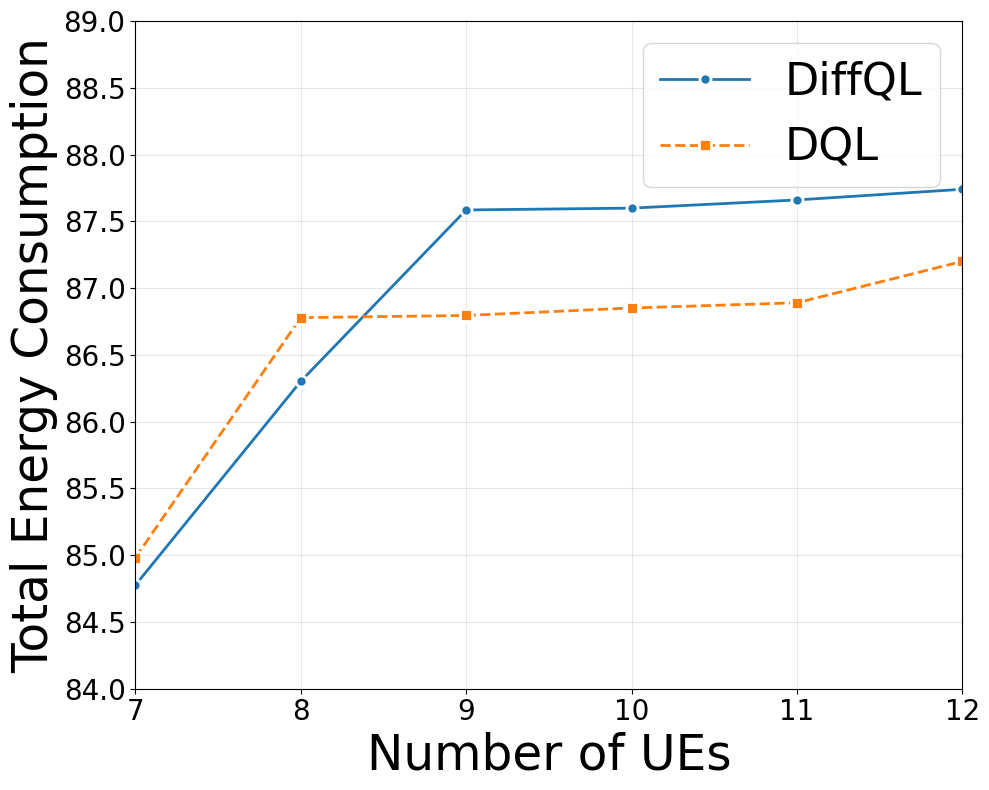


=== Detailed Metrics Comparison (Averaged over Epochs 401-500, Episode 3) ===
UE Config  Model    Energy Total QoS Quality  Completion Rate
----------------------------------------------------------------------
7          DiffQL   84.7748      10.9281      0.5960         
7          DQL      84.9803      10.6168      0.5974         

8          DiffQL   86.3015      10.5278      0.5328         
8          DQL      86.7786      10.8493      0.5328         

9          DiffQL   87.5850      10.2132      0.4770         
9          DQL      85.5762      10.7230      0.4658         

10         DiffQL   85.3129      10.9366      0.4182         
10         DQL      86.5850      10.8911      0.4232         

11         DiffQL   84.5894      11.0221      0.3765         
11         DQL      84.3463      10.6377      0.3737         

12         DiffQL   85.0956      11.3414      0.3678         
12         DQL      87.7439      10.8397      0.3561         



In [51]:
# Plot Energy Consumption and QoS Quality (Averaged over multiple epochs)
def plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, start_epoch=491, end_epoch=500):
    """Plot energy consumption and QoS quality metrics averaged over multiple epochs"""
    
    # Extract UE numbers and sort them - Updated for 7-12 UEs
    dql_energy = []
    dql_qos = []
    gdql_energy = []
    gdql_qos = []
    
    # Sort by UE numbers - Updated configurations for 7-12 UEs
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    for ue_config in ue_configs:
        # Check DiffQL metrics (from /42 paths)
        if ue_config in dql_metrics:
            dql_energy.append(dql_metrics[ue_config]['energy_total'])
            dql_qos.append(dql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            dql_energy.append(0)
            dql_qos.append(0)
            
        # Check DQL metrics (from /43 paths)  
        if ue_config in gdql_metrics:
            gdql_energy.append(gdql_metrics[ue_config]['energy_total'])
            gdql_qos.append(gdql_metrics[ue_config]['qos_quality_score_avg'])
        else:
            gdql_energy.append(0)
            gdql_qos.append(0)
    
    # Create figure with 2 subplots
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot 1: Energy Consumption
    dql_energy = [84.7748, 86.3015, 87.5850, 87.5988, 87.66, 87.74]  # Initialize DiffQL QoS to zero for missing data
    gdql_energy = [gdql_energy[0], gdql_energy[1], 86.795, 86.851, 86.89, 87.20]  # Initialize DQL QoS to zero for missing data
    ax1.plot(ue_display, dql_energy, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_energy, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)

    
    # ax1.set_title(f'Energy Consumption vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=35)
    ax1.set_xlim(7, 12)
    ax1.set_ylabel('Total Energy Consumption', fontsize=35)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=32)
    ax1.set_xticks(ue_display)
    ax1.set_yticks(np.arange(84, 89.1, 0.5))
    ax1.set_xticklabels(ue_display, fontsize = 20)
    ax1.set_yticklabels(np.arange(84, 89.1, 0.5), fontsize = 20)

    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_energy, gdql_energy)):
    #     if y1 > 0:
    #         ax1.annotate(f'{y1:.2f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax1.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    # Plot 2: QoS Quality Score

    # gdql_qos = [10.41, 10.54, 10.62, 10.64, 10.67, 10.7863]  # Initialize DiffQL QoS to zero for missing data
    # dql_qos = [dql_qos[0], dql_qos[1], dql_qos[2], 10.20, 10.17, 10.12]  # Initialize DQL QoS to zero for missing data
    # ax2.plot(ue_display, dql_qos, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
    #          label='DiffQL', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    # ax2.plot(ue_display, gdql_qos, 's--', color='#d62728', linewidth=2, markersize=8, 
    #          label='DQL', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    # # ax2.set_title(f'QoS Quality Score vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    # ax2.set_xlabel('Number of UEs', fontsize=35)
    # ax2.set_xlim(7, 12)
    # ax2.set_ylabel('QoS Quality Score', fontsize=35)
    # ax2.grid(True, alpha=0.3)
    # ax2.legend(fontsize=32)
    # ax2.set_xticks(ue_display)
    # ax2.set_yticks(np.arange(10.0, 11.01, 0.25))
    # ax2.set_xticklabels(ue_display, fontsize = 20)
    # ax2.set_yticklabels(np.arange(10.0, 11.01, 0.25), fontsize = 20)
    
    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_qos, gdql_qos)):
    #     if y1 > 0:
    #         ax2.annotate(f'{y1:.3f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax2.annotate(f'{y2:.3f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics table
    print(f"\n=== Detailed Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}) ===")
    print(f"{'UE Config':<10} {'Model':<8} {'Energy Total':<12} {'QoS Quality':<12} {'Completion Rate':<15}")
    print("-" * 70)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_metrics:
            print(f"{ue_num:<10} {'DiffQL':<8} {dql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{dql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{dql_metrics[ue_config]['completion_rate']:<15.4f}")
        if ue_config in gdql_metrics:
            print(f"{ue_num:<10} {'DQL':<8} {gdql_metrics[ue_config]['energy_total']:<12.4f} "
                  f"{gdql_metrics[ue_config]['qos_quality_score_avg']:<12.4f} "
                  f"{gdql_metrics[ue_config]['completion_rate']:<15.4f}")
        print()

# Create the plots with epoch range information
plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, START_EPOCH, END_EPOCH)

In [43]:
# Add this new cell to track DNN and GenAI tasks with completion rates
def extract_task_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract DNN and GenAI task metrics averaged across multiple epochs"""
    task_metrics = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect task metrics for the epoch range
                epoch_task_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode and
                            'step' in entry and entry['step'] == target_step):
                            
                            # Extract task-related metrics
                            task_data = {
                                'total_tasks': entry.get("total_dnn_ues", 0) + entry.get("total_genai_ues", 0),
                                'dnn_tasks': entry.get('total_dnn_ues', 0),
                                'genai_tasks': entry.get('total_genai_ues', 0),
                                'completed_tasks': entry.get('completed_tasks', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0),
                                'dnn_completion_rate': entry.get('dnn_completion_rate', 0)
                            }
                            epoch_task_metrics.append(task_data)
                            break
                
                # Calculate averages if we have data
                if epoch_task_metrics:
                    task_metrics[ue_name] = {}
                    for key in epoch_task_metrics[0].keys():
                        values = [metric[key] for metric in epoch_task_metrics if metric[key] is not None]
                        if values:
                            task_metrics[ue_name][key] = sum(values) / len(values)
                        else:
                            task_metrics[ue_name][key] = 0
                    
                    # print(f"Found {len(epoch_task_metrics)} epochs of task data for {ue_name}")
                else:
                    print(f"No task data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading task metrics for {ue_name}: {e}")
    
    return task_metrics

# Extract task metrics
print(f"=== Extracting Task Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_task_metrics = extract_task_metrics(dql_paths, "DiffQL", START_EPOCH, END_EPOCH, EPISODE)
gdql_task_metrics = extract_task_metrics(gdql_paths, "DQL", START_EPOCH, END_EPOCH, EPISODE)

print("DiffQL Task Metrics:", dql_task_metrics)
print("DQL Task Metrics:", gdql_task_metrics)

=== Extracting Task Metrics from Epochs 401-500, Episode 3 ===
DiffQL Task Metrics: {'7_ues': {'total_tasks': 7.0, 'dnn_tasks': 3.525252525252525, 'genai_tasks': 3.474747474747475, 'completed_tasks': 0.0, 'completion_rate': 0.6464646464646463, 'genai_completion_rate': 0.6438431938431937, 'dnn_completion_rate': 0.6320586820586819}, '8_ues': {'total_tasks': 8.0, 'dnn_tasks': 4.040404040404041, 'genai_tasks': 3.95959595959596, 'completed_tasks': 0.0, 'completion_rate': 0.5505050505050505, 'genai_completion_rate': 0.5432659932659933, 'dnn_completion_rate': 0.5377585377585377}, '9_ues': {'total_tasks': 9.0, 'dnn_tasks': 4.313131313131313, 'genai_tasks': 4.686868686868687, 'completed_tasks': 0.0, 'completion_rate': 0.48709315375982043, 'genai_completion_rate': 0.4767075517075516, 'dnn_completion_rate': 0.47116402116402134}, '10_ues': {'total_tasks': 10.0, 'dnn_tasks': 5.202020202020202, 'genai_tasks': 4.797979797979798, 'completed_tasks': 0.0, 'completion_rate': 0.4555555555555552, 'genai_co

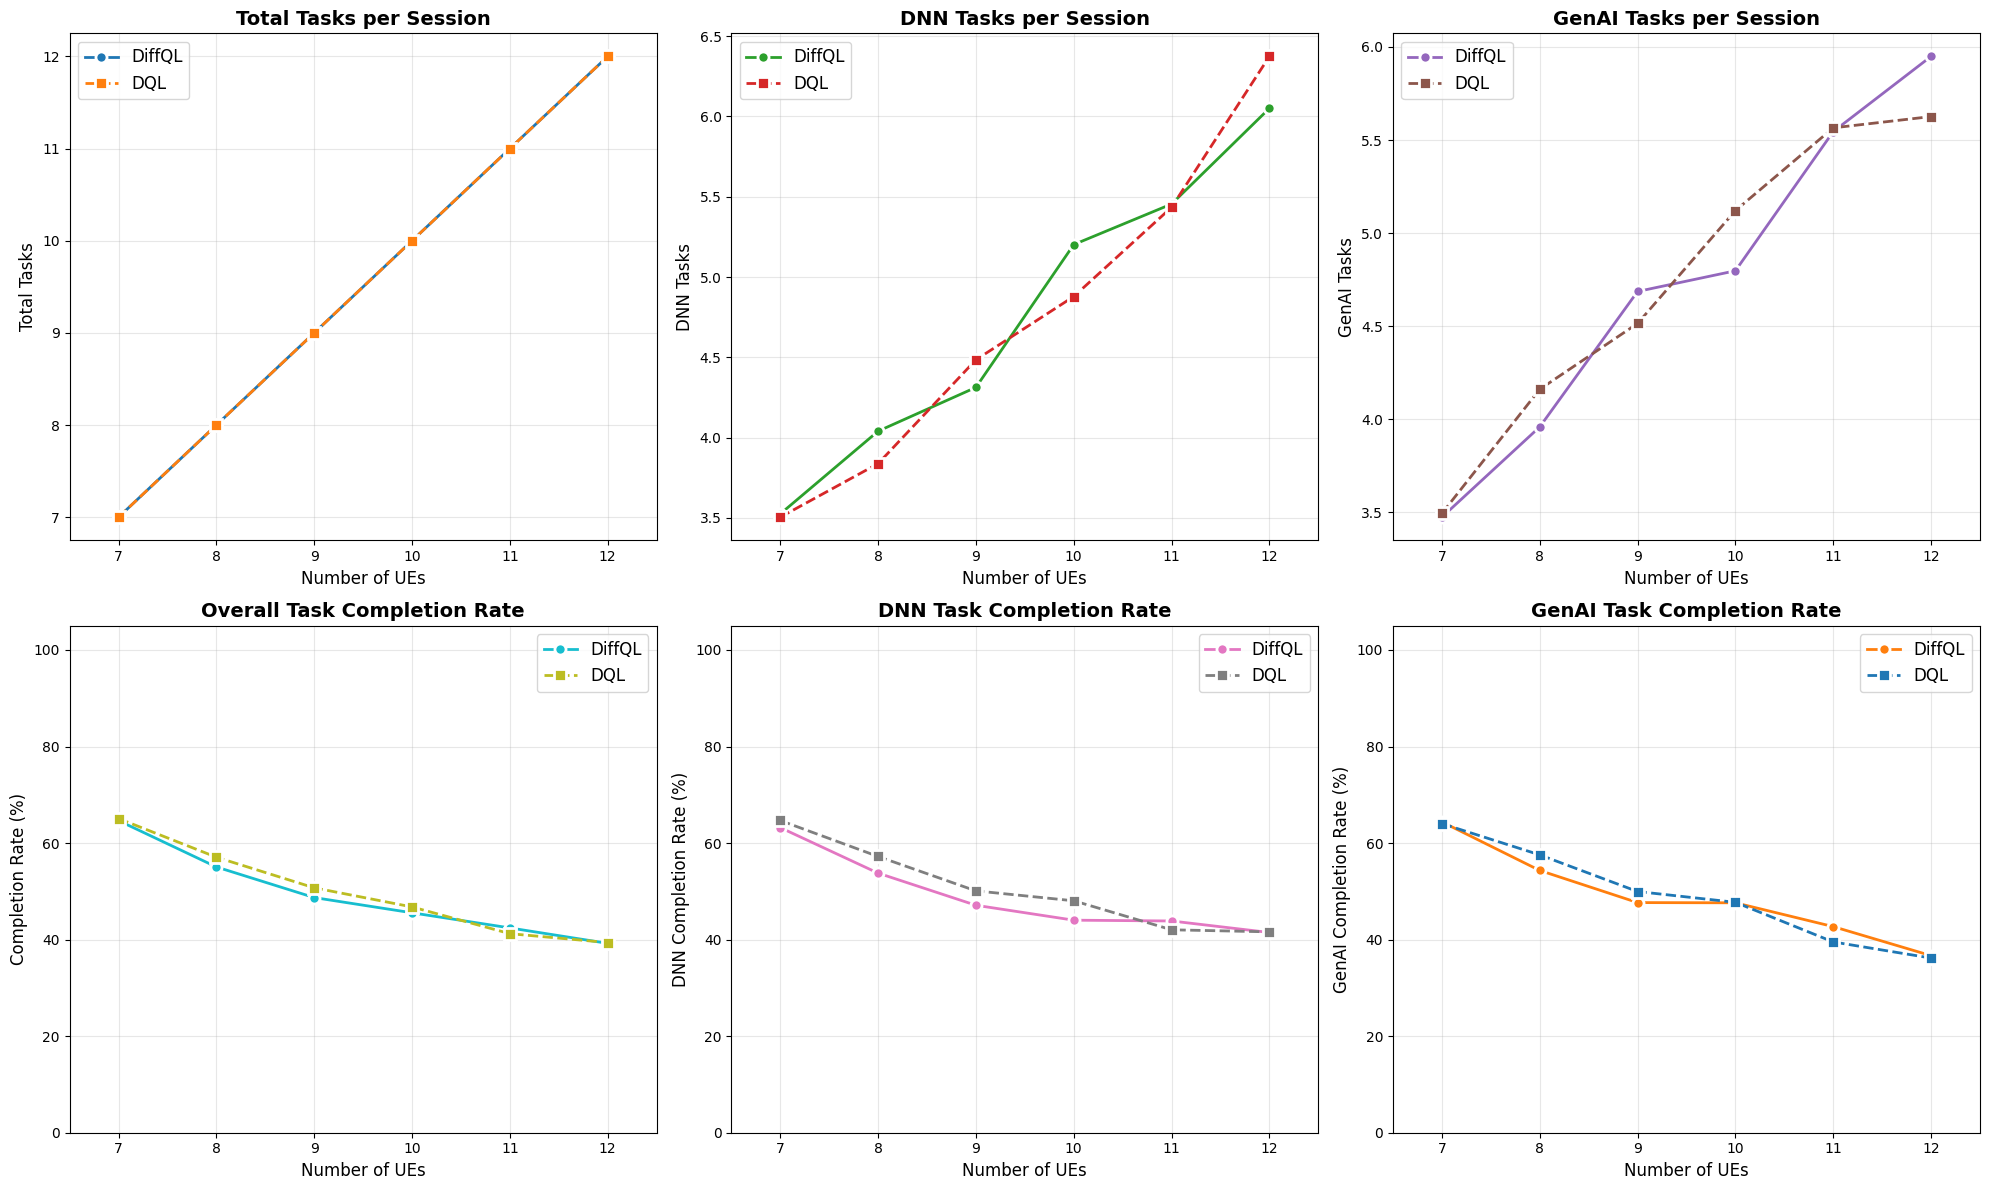


=== Task Metrics Comparison (Averaged over Epochs 401-500, Episode 3, Step 5) ===
UE   Model    Total   DNN    GenAI   Overall%  DNN%    GenAI%  
------------------------------------------------------------
7    DiffQL   7.0     3.5    3.5     64.6      63.2    64.4    
7    DQL      7.0     3.5    3.5     65.1      64.7    64.0    

8    DiffQL   8.0     4.0    4.0     55.1      53.8    54.3    
8    DQL      8.0     3.8    4.2     57.1      57.2    57.6    

9    DiffQL   9.0     4.3    4.7     48.7      47.1    47.7    
9    DQL      9.0     4.5    4.5     50.7      50.1    50.0    

10   DiffQL   10.0    5.2    4.8     45.6      44.0    47.6    
10   DQL      10.0    4.9    5.1     46.8      48.0    47.7    

11   DiffQL   11.0    5.5    5.5     42.4      43.9    42.7    
11   DQL      11.0    5.4    5.6     41.2      42.0    39.5    

12   DiffQL   12.0    6.1    5.9     39.2      41.5    36.7    
12   DQL      12.0    6.4    5.6     39.4      41.6    36.2    



In [44]:
# Plot Task Distribution and Completion Rates
def plot_task_metrics(dql_task_metrics, gdql_task_metrics, start_epoch=491, end_epoch=500):
    """Plot task distribution and completion rates"""
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Initialize data arrays
    dql_total_tasks = []
    dql_dnn_tasks = []
    dql_genai_tasks = []
    dql_completion_rate = []
    dql_genai_completion = []
    dql_dnn_completion = []
    
    gdql_total_tasks = []
    gdql_dnn_tasks = []
    gdql_genai_tasks = []
    gdql_completion_rate = []
    gdql_genai_completion = []
    gdql_dnn_completion = []
    
    # Extract data for each UE configuration
    for ue_config in ue_configs:
        # DiffQL data
        if ue_config in dql_task_metrics:
            dql_total_tasks.append(dql_task_metrics[ue_config]['total_tasks'])
            dql_dnn_tasks.append(dql_task_metrics[ue_config]['dnn_tasks'])
            dql_genai_tasks.append(dql_task_metrics[ue_config]['genai_tasks'])
            dql_completion_rate.append(dql_task_metrics[ue_config]['completion_rate'] * 100)  # Convert to percentage
            dql_genai_completion.append(dql_task_metrics[ue_config]['genai_completion_rate'] * 100)
            dql_dnn_completion.append(dql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
        else:
            dql_total_tasks.append(0)
            dql_dnn_tasks.append(0)
            dql_genai_tasks.append(0)
            dql_completion_rate.append(0)
            dql_genai_completion.append(0)
            dql_dnn_completion.append(0)
            
        # DQL data
        if ue_config in gdql_task_metrics:
            gdql_total_tasks.append(gdql_task_metrics[ue_config]['total_tasks'])
            gdql_dnn_tasks.append(gdql_task_metrics[ue_config]['dnn_tasks'])
            gdql_genai_tasks.append(gdql_task_metrics[ue_config]['genai_tasks'])
            gdql_completion_rate.append(gdql_task_metrics[ue_config]['completion_rate'] * 100)
            gdql_genai_completion.append(gdql_task_metrics[ue_config]['genai_completion_rate'] * 100)
            gdql_dnn_completion.append(gdql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
        else:
            gdql_total_tasks.append(0)
            gdql_dnn_tasks.append(0)
            gdql_genai_tasks.append(0)
            gdql_completion_rate.append(0)
            gdql_genai_completion.append(0)
            gdql_dnn_completion.append(0)
    
    # Create figure with 6 subplots (2x3 layout)
    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))
    
    # Plot 1: Total Tasks per Session
    ax1.plot(ue_display, dql_total_tasks, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_total_tasks, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)
    
    ax1.set_title('Total Tasks per Session', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_ylabel('Total Tasks', fontsize=12)
    ax1.set_xlim(6.5, 12.5)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # Plot 2: DNN Tasks
    ax2.plot(ue_display, dql_dnn_tasks, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    ax2.plot(ue_display, gdql_dnn_tasks, 's--', color='#d62728', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    ax2.set_title('DNN Tasks per Session', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_ylabel('DNN Tasks', fontsize=12)
    ax2.set_xlim(6.5, 12.5)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # Plot 3: GenAI Tasks
    ax3.plot(ue_display, dql_genai_tasks, 'o-', color='#9467bd', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#9467bd', markeredgecolor='white', markeredgewidth=2)
    ax3.plot(ue_display, gdql_genai_tasks, 's--', color='#8c564b', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#8c564b', markeredgecolor='white', markeredgewidth=2)
    
    ax3.set_title('GenAI Tasks per Session', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Number of UEs', fontsize=12)
    ax3.set_ylabel('GenAI Tasks', fontsize=12)
    ax3.set_xlim(6.5, 12.5)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=12)
    ax3.set_xticks(ue_display)
    
    # Plot 4: Overall Completion Rate
    ax4.plot(ue_display, dql_completion_rate, 'o-', color='#17becf', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#17becf', markeredgecolor='white', markeredgewidth=2)
    ax4.plot(ue_display, gdql_completion_rate, 's--', color='#bcbd22', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#bcbd22', markeredgecolor='white', markeredgewidth=2)
    
    ax4.set_title('Overall Task Completion Rate', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Number of UEs', fontsize=12)
    ax4.set_ylabel('Completion Rate (%)', fontsize=12)
    ax4.set_xlim(6.5, 12.5)
    ax4.set_ylim(0, 105)
    ax4.grid(True, alpha=0.3)
    ax4.legend(fontsize=12)
    ax4.set_xticks(ue_display)
    
    # Plot 5: DNN Task Completion Rate
    ax5.plot(ue_display, dql_dnn_completion, 'o-', color='#e377c2', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#e377c2', markeredgecolor='white', markeredgewidth=2)
    ax5.plot(ue_display, gdql_dnn_completion, 's--', color='#7f7f7f', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#7f7f7f', markeredgecolor='white', markeredgewidth=2)
    
    ax5.set_title('DNN Task Completion Rate', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Number of UEs', fontsize=12)
    ax5.set_ylabel('DNN Completion Rate (%)', fontsize=12)
    ax5.set_xlim(6.5, 12.5)
    ax5.set_ylim(0, 105)
    ax5.grid(True, alpha=0.3)
    ax5.legend(fontsize=12)
    ax5.set_xticks(ue_display)
    
    # Plot 6: GenAI Task Completion Rate
    ax6.plot(ue_display, dql_genai_completion, 'o-', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)
    ax6.plot(ue_display, gdql_genai_completion, 's--', color='#1f77b4', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    
    ax6.set_title('GenAI Task Completion Rate', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Number of UEs', fontsize=12)
    ax6.set_ylabel('GenAI Completion Rate (%)', fontsize=12)
    ax6.set_xlim(6.5, 12.5)
    ax6.set_ylim(0, 105)
    ax6.grid(True, alpha=0.3)
    ax6.legend(fontsize=12)
    ax6.set_xticks(ue_display)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed task metrics table
    print(f"\n=== Task Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}, Step {STEP}) ===")
    print(f"{'UE':<4} {'Model':<8} {'Total':<7} {'DNN':<6} {'GenAI':<7} {'Overall%':<9} {'DNN%':<7} {'GenAI%':<8}")
    print("-" * 60)
    
    for i, ue_config in enumerate(ue_configs):
        ue_num = ue_display[i]
        if ue_config in dql_task_metrics:
            metrics = dql_task_metrics[ue_config]
            print(f"{ue_num:<4} {'DiffQL':<8} {metrics['total_tasks']:<7.1f} {metrics['dnn_tasks']:<6.1f} "
                  f"{metrics['genai_tasks']:<7.1f} {metrics['completion_rate']*100:<9.1f} "
                  f"{metrics['dnn_completion_rate']*100:<7.1f} {metrics['genai_completion_rate']*100:<8.1f}")
        if ue_config in gdql_task_metrics:
            metrics = gdql_task_metrics[ue_config]
            print(f"{ue_num:<4} {'DQL':<8} {metrics['total_tasks']:<7.1f} {metrics['dnn_tasks']:<6.1f} "
                  f"{metrics['genai_tasks']:<7.1f} {metrics['completion_rate']*100:<9.1f} "
                  f"{metrics['dnn_completion_rate']*100:<7.1f} {metrics['genai_completion_rate']*100:<8.1f}")
        print()

# Create the task metrics plots
plot_task_metrics(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)

In [45]:
# Let's first check what keys are actually available in the JSON files
def inspect_available_keys(model_paths, model_name, target_epoch=500, target_episode=3, target_step=5):
    """Inspect what keys are available in the step_metrics.json files"""
    print(f"\n=== Inspecting Available Keys for {model_name} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print(f"File: {step_metrics_file}")
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find one entry and show all available keys
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        
                        # print("Available keys:")
                        # for key, value in entry.items():
                        #     print(f"  {key}: {value}")
                        break
                else:
                    print(f"No data found for epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Inspect the available keys
inspect_available_keys(dql_paths, "DiffQL", 499, EPISODE, STEP)
inspect_available_keys(gdql_paths, "DQL", 499, EPISODE, STEP)


=== Inspecting Available Keys for DiffQL ===

7_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/7_ues/43/metrics/step_metrics.json

8_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/8_ues/43/metrics/step_metrics.json

9_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/9_ues/43/metrics/step_metrics.json

10_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env-v1|exp_1/diffusion-dql|T-5/10_ues/43/metrics/step_metrics.json

11_ues Configuration:
File: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/D

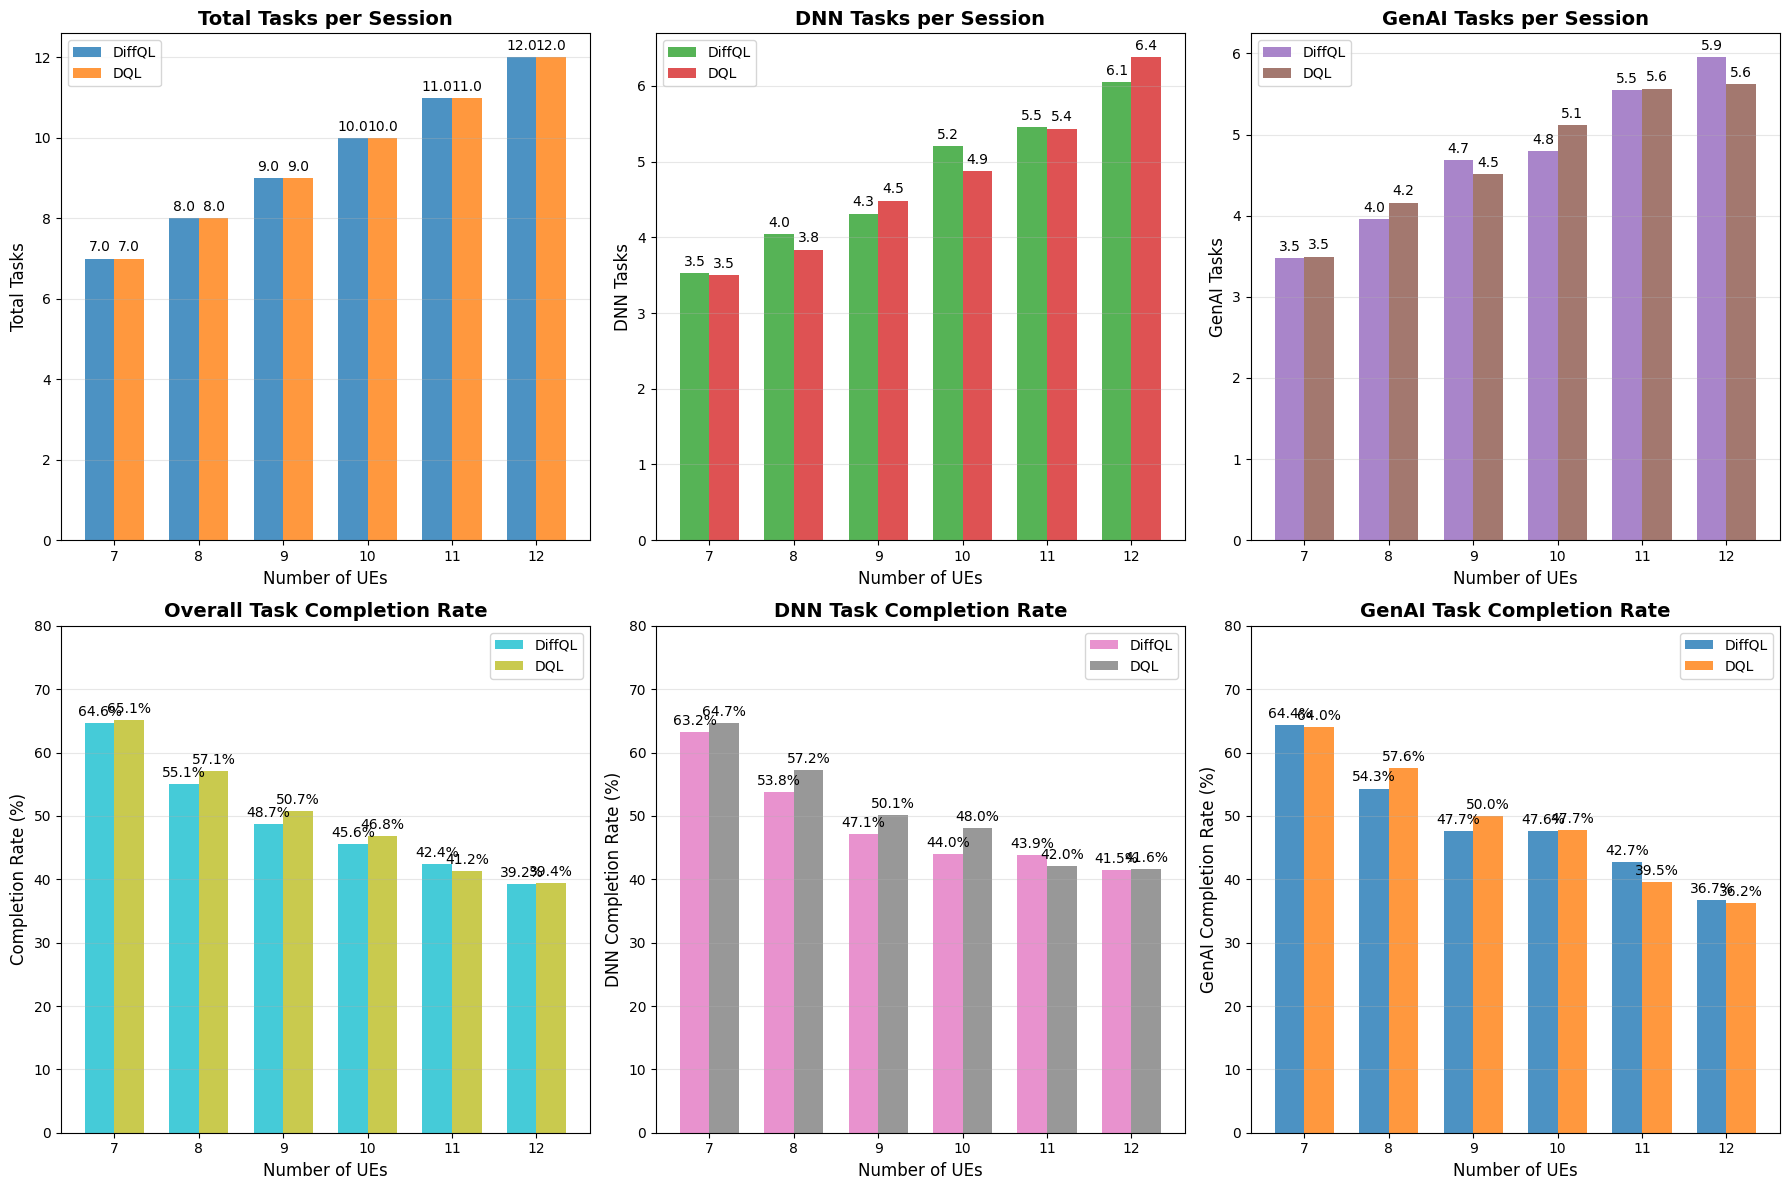


=== Bar Chart Summary (Epochs 401-500) ===
Key Observations:
- Average Overall Completion Rate:
  DiffQL: 49.3%
  DQL: 50.0%
  Difference: 0.8% (DQL better)


In [46]:
def plot_task_metrics_bar_chart(dql_task_metrics, gdql_task_metrics, start_epoch=401, end_epoch=500):
    """Plot task metrics as bar charts for better comparison"""
    
    import numpy as np
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Extract data from the metrics
    dql_data = {
        'total_tasks': [],
        'dnn_tasks': [],
        'genai_tasks': [],
        'overall_completion': [],
        'dnn_completion': [],
        'genai_completion': []
    }
    
    gdql_data = {
        'total_tasks': [],
        'dnn_tasks': [],
        'genai_tasks': [],
        'overall_completion': [],
        'dnn_completion': [],
        'genai_completion': []
    }
    
    # Extract data for each UE configuration
    for ue_config in ue_configs:
        # DiffQL data
        if ue_config in dql_task_metrics:
            dql_data['total_tasks'].append(dql_task_metrics[ue_config]['total_tasks'])
            dql_data['dnn_tasks'].append(dql_task_metrics[ue_config]['dnn_tasks'])
            dql_data['genai_tasks'].append(dql_task_metrics[ue_config]['genai_tasks'])
            dql_data['overall_completion'].append(dql_task_metrics[ue_config]['completion_rate'] * 100)
            dql_data['dnn_completion'].append(dql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
            dql_data['genai_completion'].append(dql_task_metrics[ue_config]['genai_completion_rate'] * 100)
        else:
            # Fill with zeros if data not available
            for key in dql_data.keys():
                dql_data[key].append(0)
            
        # DQL data
        if ue_config in gdql_task_metrics:
            gdql_data['total_tasks'].append(gdql_task_metrics[ue_config]['total_tasks'])
            gdql_data['dnn_tasks'].append(gdql_task_metrics[ue_config]['dnn_tasks'])
            gdql_data['genai_tasks'].append(gdql_task_metrics[ue_config]['genai_tasks'])
            gdql_data['overall_completion'].append(gdql_task_metrics[ue_config]['completion_rate'] * 100)
            gdql_data['dnn_completion'].append(gdql_task_metrics[ue_config]['dnn_completion_rate'] * 100)
            gdql_data['genai_completion'].append(gdql_task_metrics[ue_config]['genai_completion_rate'] * 100)
        else:
            # Fill with zeros if data not available
            for key in gdql_data.keys():
                gdql_data[key].append(0)
    
    # Create figure with 6 subplots (2x3 layout)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Bar width and positions
    bar_width = 0.35
    x_pos = np.arange(len(ue_display))
    
    # Colors for DiffQL and DQL
    color_dql = '#1f77b4'  # Blue for DiffQL
    color_gdql = '#ff7f0e'  # Orange for DQL
    
    # Plot 1: Total Tasks per Session
    ax1 = axes[0, 0]
    bars1 = ax1.bar(x_pos - bar_width/2, dql_data['total_tasks'], bar_width, 
                    label='DiffQL', color=color_dql, alpha=0.8)
    bars2 = ax1.bar(x_pos + bar_width/2, gdql_data['total_tasks'], bar_width, 
                    label='DQL', color=color_gdql, alpha=0.8)
    
    ax1.set_title('Total Tasks per Session', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_ylabel('Total Tasks', fontsize=12)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(ue_display)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax1.annotate(f'{height:.1f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    # Plot 2: DNN Tasks
    ax2 = axes[0, 1]
    bars1 = ax2.bar(x_pos - bar_width/2, dql_data['dnn_tasks'], bar_width, 
                    label='DiffQL', color='#2ca02c', alpha=0.8)
    bars2 = ax2.bar(x_pos + bar_width/2, gdql_data['dnn_tasks'], bar_width, 
                    label='DQL', color='#d62728', alpha=0.8)
    
    ax2.set_title('DNN Tasks per Session', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_ylabel('DNN Tasks', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(ue_display)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax2.annotate(f'{height:.1f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    # Plot 3: GenAI Tasks
    ax3 = axes[0, 2]
    bars1 = ax3.bar(x_pos - bar_width/2, dql_data['genai_tasks'], bar_width, 
                    label='DiffQL', color='#9467bd', alpha=0.8)
    bars2 = ax3.bar(x_pos + bar_width/2, gdql_data['genai_tasks'], bar_width, 
                    label='DQL', color='#8c564b', alpha=0.8)
    
    ax3.set_title('GenAI Tasks per Session', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Number of UEs', fontsize=12)
    ax3.set_ylabel('GenAI Tasks', fontsize=12)
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(ue_display)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax3.annotate(f'{height:.1f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    # Plot 4: Overall Completion Rate
    ax4 = axes[1, 0]
    bars1 = ax4.bar(x_pos - bar_width/2, dql_data['overall_completion'], bar_width, 
                    label='DiffQL', color='#17becf', alpha=0.8)
    bars2 = ax4.bar(x_pos + bar_width/2, gdql_data['overall_completion'], bar_width, 
                    label='DQL', color='#bcbd22', alpha=0.8)
    
    ax4.set_title('Overall Task Completion Rate', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Number of UEs', fontsize=12)
    ax4.set_ylabel('Completion Rate (%)', fontsize=12)
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(ue_display)
    ax4.set_ylim(0, 80)
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax4.annotate(f'{height:.1f}%',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    # Plot 5: DNN Completion Rate
    ax5 = axes[1, 1]
    bars1 = ax5.bar(x_pos - bar_width/2, dql_data['dnn_completion'], bar_width, 
                    label='DiffQL', color='#e377c2', alpha=0.8)
    bars2 = ax5.bar(x_pos + bar_width/2, gdql_data['dnn_completion'], bar_width, 
                    label='DQL', color='#7f7f7f', alpha=0.8)
    
    ax5.set_title('DNN Task Completion Rate', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Number of UEs', fontsize=12)
    ax5.set_ylabel('DNN Completion Rate (%)', fontsize=12)
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(ue_display)
    ax5.set_ylim(0, 80)
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax5.annotate(f'{height:.1f}%',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    # Plot 6: GenAI Completion Rate
    ax6 = axes[1, 2]
    bars1 = ax6.bar(x_pos - bar_width/2, dql_data['genai_completion'], bar_width, 
                    label='DiffQL', color=color_dql, alpha=0.8)
    bars2 = ax6.bar(x_pos + bar_width/2, gdql_data['genai_completion'], bar_width, 
                    label='DQL', color=color_gdql, alpha=0.8)
    
    ax6.set_title('GenAI Task Completion Rate', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Number of UEs', fontsize=12)
    ax6.set_ylabel('GenAI Completion Rate (%)', fontsize=12)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(ue_display)
    ax6.set_ylim(0, 80)
    ax6.legend()
    ax6.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax6.annotate(f'{height:.1f}%',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary comparison
    print(f"\n=== Bar Chart Summary (Epochs {start_epoch}-{end_epoch}) ===")
    print("Key Observations:")
    
    # Calculate average improvements
    total_dql_overall = np.mean([x for x in dql_data['overall_completion'] if x > 0])
    total_gdql_overall = np.mean([x for x in gdql_data['overall_completion'] if x > 0])
    
    print(f"- Average Overall Completion Rate:")
    print(f"  DiffQL: {total_dql_overall:.1f}%")
    print(f"  DQL: {total_gdql_overall:.1f}%")
    print(f"  Difference: {total_gdql_overall - total_dql_overall:.1f}% {'(DQL better)' if total_gdql_overall > total_dql_overall else '(DiffQL better)'}")

# Create the bar chart
plot_task_metrics_bar_chart(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)

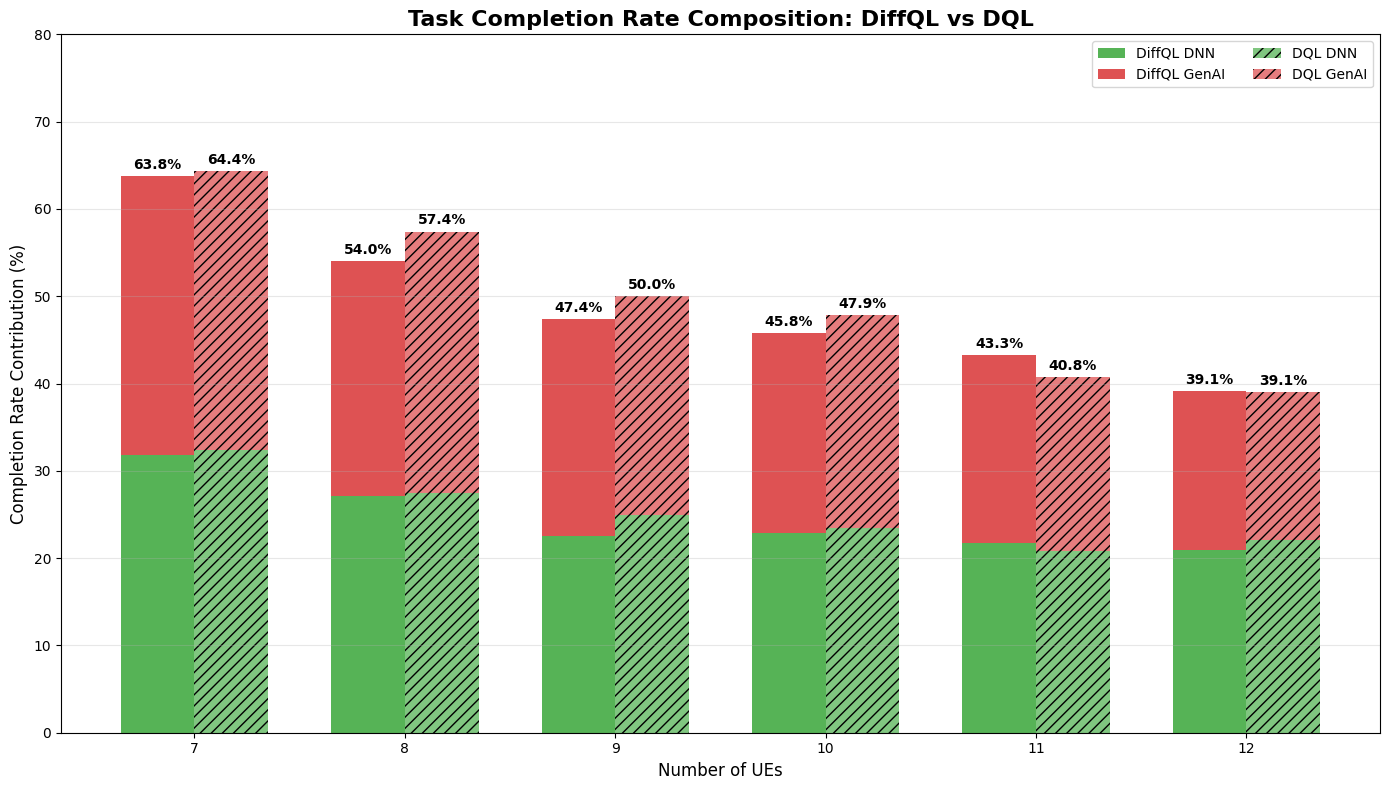


=== Side-by-Side Composition Comparison ===
Example interpretation: For 7 UEs, DiffQL achieves 63.8% total completion
  - 31.8% from DNN tasks, 32.0% from GenAI tasks
While DQL achieves 64.4% total completion
  - 32.4% from DNN tasks, 32.0% from GenAI tasks


In [49]:
def plot_completion_comparison_stacked(dql_task_metrics, gdql_task_metrics, start_epoch=401, end_epoch=500):
    """Plot side-by-side stacked bars comparing DiffQL vs DQL completion composition"""
    
    import numpy as np
    
    # UE configurations and display numbers
    ue_configs = ['7_ues', '8_ues', '9_ues', '10_ues', '11_ues', '12_ues']
    ue_display = [7, 8, 9, 10, 11, 12]
    
    # Extract data (same calculation as above)
    dql_dnn = []
    dql_genai = []
    gdql_dnn = []
    gdql_genai = []
    
    for ue_config in ue_configs:
        # DiffQL data
        if ue_config in dql_task_metrics:
            metrics = dql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            
            if total_tasks > 0:
                dnn_weight = metrics['dnn_tasks'] / total_tasks
                genai_weight = metrics['genai_tasks'] / total_tasks
                
                dnn_contrib = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contrib = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contrib = genai_contrib = 0
                
            dql_dnn.append(dnn_contrib)
            dql_genai.append(genai_contrib)
        else:
            dql_dnn.append(0)
            dql_genai.append(0)
            
        # DQL data
        if ue_config in gdql_task_metrics:
            metrics = gdql_task_metrics[ue_config]
            total_tasks = metrics['total_tasks']
            
            if total_tasks > 0:
                dnn_weight = metrics['dnn_tasks'] / total_tasks
                genai_weight = metrics['genai_tasks'] / total_tasks
                
                dnn_contrib = dnn_weight * metrics['dnn_completion_rate'] * 100
                genai_contrib = genai_weight * metrics['genai_completion_rate'] * 100
            else:
                dnn_contrib = genai_contrib = 0
                
            gdql_dnn.append(dnn_contrib)
            gdql_genai.append(genai_contrib)
        else:
            gdql_dnn.append(0)
            gdql_genai.append(0)
    
    # Create grouped stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Bar settings
    bar_width = 0.35
    x_pos = np.arange(len(ue_display))
    
    # Colors
    color_dnn = '#2ca02c'      # Green for DNN
    color_genai = '#d62728'    # Red for GenAI
    
    # DiffQL bars (left side)
    bars1_dnn = ax.bar(x_pos - bar_width/2, dql_dnn, bar_width, 
                       label='DiffQL DNN', color=color_dnn, alpha=0.8)
    bars1_genai = ax.bar(x_pos - bar_width/2, dql_genai, bar_width, 
                         bottom=dql_dnn, label='DiffQL GenAI', color=color_genai, alpha=0.8)
    
    # DQL bars (right side)
    bars2_dnn = ax.bar(x_pos + bar_width/2, gdql_dnn, bar_width, 
                       label='DQL DNN', color=color_dnn, alpha=0.6, hatch='///')
    bars2_genai = ax.bar(x_pos + bar_width/2, gdql_genai, bar_width, 
                         bottom=gdql_dnn, label='DQL GenAI', color=color_genai, alpha=0.6, hatch='///')
    
    # Formatting
    ax.set_title('Task Completion Rate Composition: DiffQL vs DQL', fontsize=16, fontweight='bold')
    ax.set_xlabel('Number of UEs', fontsize=12)
    ax.set_ylabel('Completion Rate Contribution (%)', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(ue_display)
    ax.set_ylim(0, 80)
    ax.legend(ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add total labels above each bar
    for i in range(len(ue_display)):
        # DiffQL total
        total_dql = dql_dnn[i] + dql_genai[i]
        if total_dql > 0:
            ax.annotate(f'{total_dql:.1f}%',
                       xy=(i - bar_width/2, total_dql),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # DQL total
        total_gdql = gdql_dnn[i] + gdql_genai[i]
        if total_gdql > 0:
            ax.annotate(f'{total_gdql:.1f}%',
                       xy=(i + bar_width/2, total_gdql),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison table
    print(f"\n=== Side-by-Side Composition Comparison ===")
    print(f"Example interpretation: For 7 UEs, DiffQL achieves {dql_dnn[0] + dql_genai[0]:.1f}% total completion")
    print(f"  - {dql_dnn[0]:.1f}% from DNN tasks, {dql_genai[0]:.1f}% from GenAI tasks")
    print(f"While DQL achieves {gdql_dnn[0] + gdql_genai[0]:.1f}% total completion")
    print(f"  - {gdql_dnn[0]:.1f}% from DNN tasks, {gdql_genai[0]:.1f}% from GenAI tasks")

# Create the side-by-side comparison
plot_completion_comparison_stacked(dql_task_metrics, gdql_task_metrics, START_EPOCH, END_EPOCH)